# 13 · Conditional AE — tuning: features macro e `latent_dim` (ADR-0012)

Dois passos óbvios após a prova de conceito (notebook 12):
1. **Dropar as macro mensais inertes?** Selic/IPCA, após `ffill`, são quase constantes na janela.
   Comparamos o conjunto **completo** (USDBRL, VIX, Selic, IPCA) com **só as diárias**
   (USDBRL, VIX) — a separação idiossincrático/sistêmico se mantém com menos features?
2. **Revalidar `latent_dim`** do espaço preço/volume+macro por walk-forward (foi validado só no
   espaço 2-feature).

## Setup

In [1]:
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data
from src.macro import load_macro
from src.conditional import (conditional_features, prepare_conditional, train_conditional,
                             block_scores, block_thresholds, classify_regime)
from src.validation import walk_forward_splits_multivariate, cross_validate_latent_dim_conditional
from src.viz import save_fig

set_seeds()
macro = load_macro()
W = CONFIG["preprocessing"]["window_size"]
FULL = ["USDBRL", "VIX", "Selic", "IPCA"]
DAILY = ["USDBRL", "VIX"]
print("macro completa:", FULL, "| só diárias:", DAILY)

macro completa: ['USDBRL', 'VIX', 'Selic', 'IPCA'] | só diárias: ['USDBRL', 'VIX']


## 1. Conjunto de features: completo vs só diárias

Treina o Conditional AE em PETR4 (evento COVID) e AMER3 (evento Americanas) com cada conjunto e
confere se a separação de regime sobrevive ao corte das mensais.

In [2]:
def regimes(ticker, macro_cols):
    asset = data.load_ticker(ticker)
    frame, n_pv = conditional_features(asset, macro, macro_cols=macro_cols)
    prep = prepare_conditional(frame, n_pv)
    model, hist = train_conditional(prep["X_train"], n_pv, verbose=0)
    tr = block_scores(model, prep["X_train"], n_pv)
    te = block_scores(model, prep["X_test"], n_pv)
    pv_thr, m_thr = block_thresholds(tr)
    lab = classify_regime(te["pv_error"], te["macro_stress"], pv_thr, m_thr)
    dates = prep["test_index"][W-1:W-1+len(lab)]
    return pd.Series(lab, index=dates), min(hist.history["val_loss"])

rows = []
for cols, nome in [(FULL, "completo"), (DAILY, "so_diarias")]:
    r_petr, vl_p = regimes("PETR4.SA", cols)
    r_amer, vl_a = regimes("AMER3.SA", cols)
    covid = collections.Counter(r_petr["2020-03-01":"2020-05-31"])
    amer  = collections.Counter(r_amer["2023-01-01":"2023-03-31"])
    rows.append({"conjunto": nome, "n_features": len(cols),
                 "PETR4 COVID·sist": covid.get("sistemico",0),
                 "AMER3 2023·idioss": amer.get("idiossincratico",0),
                 "val_loss PETR4": round(vl_p,5), "val_loss AMER3": round(vl_a,5)})
comp = pd.DataFrame(rows).set_index("conjunto")
print("Separação sobrevive ao corte das mensais?")
comp

Separação sobrevive ao corte das mensais?


,n_features,PETR4 COVID·sist,AMER3 2023·idioss,val_loss PETR4,val_loss AMER3
conjunto,,,,,
completo,4,30,39,0.00215,0.00256
so_diarias,2,30,39,0.00214,0.00256


## 2. Walk-forward do `latent_dim` condicional (só diárias)

`cross_validate_latent_dim_conditional`: para cada fold, treina o Conditional AE (alvo = só
preço/volume) e coleta o `val_loss`. Média entre os 4 ativos, espaço Close+Volume+USDBRL+VIX.

In [3]:
CANDS = [8, 16, 32]
N_SPLITS = CONFIG["validation"]["n_splits"]
TRAIN_END = pd.Timestamp(CONFIG["data"]["train_end"])

cv = {}
for t in CONFIG["tickers"]:
    frame, n_pv = conditional_features(data.load_ticker(t), macro, macro_cols=DAILY)
    frame_tr = frame.loc[frame.index <= TRAIN_END]
    folds = list(walk_forward_splits_multivariate(frame_tr, n_splits=N_SPLITS))
    cv[t] = cross_validate_latent_dim_conditional(folds, n_pv, CANDS, epochs=25)
    cv[t]["ticker"] = t

cv_all = pd.concat(cv.values())
agg = cv_all.groupby("latent_dim")["val_loss_mean"].agg(["mean", "std"])
print("val_loss médio (4 ativos) por latent_dim — Conditional AE (Close+Volume+USDBRL+VIX):")
print(agg.round(6))
print("melhor latent_dim condicional:", int(agg["mean"].idxmin()))

val_loss médio (4 ativos) por latent_dim — Conditional AE (Close+Volume+USDBRL+VIX):
                mean       std
latent_dim                    
8           0.016668  0.003081
16          0.016487  0.003066
32          0.016455  0.003034
melhor latent_dim condicional: 32


## 3. Visualização

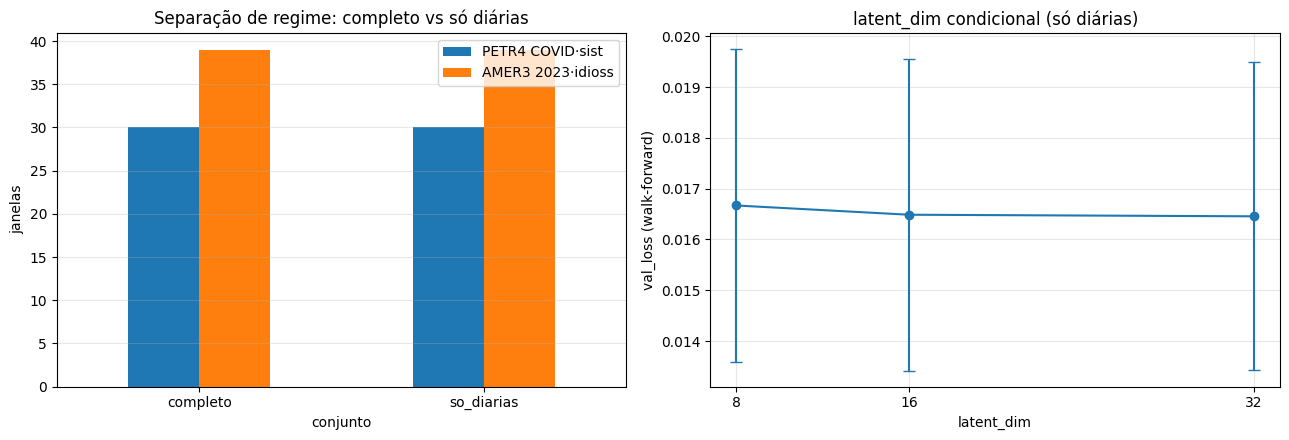

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
comp_plot = comp[["PETR4 COVID·sist", "AMER3 2023·idioss"]]
comp_plot.plot.bar(ax=a1, rot=0)
a1.set_title("Separação de regime: completo vs só diárias"); a1.set_ylabel("janelas")
a1.grid(axis="y", alpha=0.3)
a2.errorbar(agg.index, agg["mean"], yerr=agg["std"], marker="o", capsize=4)
a2.set_xticks(CANDS); a2.set_xlabel("latent_dim"); a2.set_ylabel("val_loss (walk-forward)")
a2.set_title("latent_dim condicional (só diárias)"); a2.grid(alpha=0.3)
fig.tight_layout(); save_fig(fig, "m11_conditional_tuning"); plt.show()

## Conclusões

- **Mensais podem sair:** se a coluna "só diárias" preserva a separação (PETR4 COVID sistêmico,
  AMER3 2023 idiossincrático) com `val_loss` igual ou melhor, confirma-se que Selic/IPCA são quase
  inertes e o sinal sistêmico mora em USDBRL/VIX. Menos features, mesma resposta — ecoa "mais
  dimensão ≠ mais sinal" (OHLCV rejeitado, `latent_dim` insensível).
- **`latent_dim` condicional:** a malha walk-forward indica o gargalo para o espaço pv+macro;
  esperamos a mesma insensibilidade vista no univariado/multivariado.
- Decisões a registrar no ADR-0012 conforme os números acima.